### Part 1 - Data Preparation
Prepare and preprocess the dataset for machine learning model training.

#### Tasks
1. Load the dataset using Pandas.
2. Explore the dataset:
   - a. Shape of the dataset
   - b. Column names
   - c. Data types
   - d. Missing values (including logical missing values)
   - e. Basic statistical summary
3. Separate the dataset into:
   - a. Features (X)
   - b. Target variable (y)
4. Perform a train-test split.
5. Perform preprocessing:
   - a. Handle missing values
   - b. Encode categorical variables, if any
   - c. Scale/standardize numerical features where appropriate

In [42]:
# Part 1.1: Load required libraries and dataset
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

file_path = 'diabetes.csv'
df = pd.read_csv(file_path)

print('1) Dataset loaded successfully.')
print(f'   Shape: {df.shape}')
df.head()

1) Dataset loaded successfully.
   Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [43]:
# Part 1.2: Explore structure, types, missingness, and summary
print('2a) Shape of dataset:')
print(df.shape)

print('\n2b) Column names:')
print(df.columns.tolist())

print('\n2c) Data types:')
print(df.dtypes)

print('\n2d) Missing values (raw NaN):')
raw_missing = df.isna().sum()
print(raw_missing)

# In this dataset, zero values are physiologically invalid for some medical measurements.
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
logical_missing = (df[zero_as_missing_cols] == 0).sum()

missing_summary = pd.DataFrame({
    'Raw Missing (NaN)': raw_missing,
    'Logical Missing (Zero-as-Missing)': 0
})
missing_summary.loc[zero_as_missing_cols, 'Logical Missing (Zero-as-Missing)'] = logical_missing.values

print('\nMissing summary (raw + logical):')
display(missing_summary)

print('2e) Basic statistical summary:')
display(df.describe().T)

2a) Shape of dataset:
(768, 9)

2b) Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

2c) Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

2d) Missing values (raw NaN):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing summary (raw + logical):


,Raw Missing (NaN),Logical Missing (Zero-as-Missing)
Pregnancies,0,0
Glucose,0,5
BloodPressure,0,35
SkinThickness,0,227
Insulin,0,374
BMI,0,11
DiabetesPedigreeFunction,0,0
Age,0,0
Outcome,0,0


2e) Basic statistical summary:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [44]:
# Part 1.3: Separate features and target variable
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print('3a) Features (X) preview:')
display(X.head())
print('\n3b) Target variable (y) distribution:')
print(y.value_counts().sort_index())
print('Class ratio (normalized):')
print(y.value_counts(normalize=True).sort_index().round(3))

3a) Features (X) preview:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



3b) Target variable (y) distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Class ratio (normalized):
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


### Part 1 - Features and Target Description

- Features (X): All predictor columns are used as input variables:
  - Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
- Target (y): `Outcome`
  - `0` indicates no diabetes
  - `1` indicates diabetes
- Problem type: Supervised binary classification.

In [45]:
# Part 1.4: Train-test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('4) Train-test split completed.')
print(f'   X_train shape: {X_train.shape}')
print(f'   X_test shape:  {X_test.shape}')
print(f'   y_train shape: {y_train.shape}')
print(f'   y_test shape:  {y_test.shape}')

print('\nClass distribution after split:')
print('Train:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('Test:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

4) Train-test split completed.
   X_train shape: (614, 8)
   X_test shape:  (154, 8)
   y_train shape: (614,)
   y_test shape:  (154,)

Class distribution after split:
Train:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64
Test:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [46]:
# Part 1.5: Preprocessing pipeline
# Step A: convert logical missing zeros to NaN for selected columns
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    X_train_prep[col] = X_train_prep[col].replace(0, np.nan)
    X_test_prep[col] = X_test_prep[col].replace(0, np.nan)

numeric_features = X_train_prep.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_prep.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train_prep)
X_test_processed = preprocessor.transform(X_test_prep)

print('5) Preprocessing completed.')
print(f'   Numeric features: {numeric_features}')
print(f'   Categorical features: {categorical_features if categorical_features else "None"}')
print(f'   Processed X_train shape: {X_train_processed.shape}')
print(f'   Processed X_test shape:  {X_test_processed.shape}')

5) Preprocessing completed.
   Numeric features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
   Categorical features: None
   Processed X_train shape: (614, 8)
   Processed X_test shape:  (154, 8)


### Part 2 - Machine Learning Model Building
Build a suitable classification model using Scikit-learn.

#### Tasks
1. Import the required Python and Scikit-learn libraries.
2. Select and implement an appropriate classification algorithm, such as:
   - a. Logistic Regression
   - b. Decision Tree Classifier
   - c. Random Forest Classifier
3. Train the selected Machine Learning model using the training dataset.
4. Explain:
   - a. Why the selected algorithm is suitable for this problem
   - b. Key parameters used in the model
   - c. How the model makes predictions
5. If multiple algorithms are implemented, compare their performance and identify the best-performing model.

In [47]:
# Part 2.1 to 2.3: import models, define algorithms, and train on training data
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = []
trained_models = {}

for model_name, model in models.items():
    scores = cross_validate(
        estimator=model,
        X=X_train_processed,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'Model': model_name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1': scores['test_f1'].mean()
    })

    model.fit(X_train_processed, y_train)
    trained_models[model_name] = model

comparison_df = pd.DataFrame(cv_results).sort_values('CV F1', ascending=False).reset_index(drop=True)
best_model_name = comparison_df.loc[0, 'Model']
selected_model = trained_models[best_model_name]

print('Part 2 model training completed for all selected algorithms.')
print(f'Selected best model based on CV F1: {best_model_name}')
print('\nCross-validation comparison:')
display(comparison_df.round(4))

Part 2 model training completed for all selected algorithms.
Selected best model based on CV F1: Logistic Regression

Cross-validation comparison:


,Model,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,0.7866,0.7623,0.5701,0.6511
1,Random Forest,0.7720,0.7133,0.5888,0.6434
2,Decision Tree,0.7247,0.6208,0.5415,0.5737


### Part 2 - Explanations

1. Why these algorithms are suitable:
- Logistic Regression is a strong baseline for binary classification, is fast, and gives interpretable coefficients.
- Decision Tree captures nonlinear relationships and feature interactions with transparent decision rules.
- Random Forest reduces overfitting risk of a single tree by averaging many trees, usually improving generalization.

2. Key parameters used:
- Logistic Regression: `max_iter=1000` for stable convergence.
- Decision Tree: `max_depth=5`, `min_samples_split=10` to control complexity.
- Random Forest: `n_estimators=300`, `max_depth=8`, `min_samples_split=10` for robust ensemble performance.

3. How predictions are made:
- Logistic Regression estimates probability of class 1 and applies a threshold.
- Decision Tree routes a sample through split rules to a leaf and predicts leaf class.
- Random Forest aggregates votes/probabilities from many trees and outputs the majority/probability-based class.

### Part 3 - Model Training
Train the Machine Learning model using the prepared training dataset.

#### Tasks
1. Fit the selected model using the training dataset.
2. Generate predictions on the training dataset.
3. Evaluate the model's training performance.
4. Check for potential overfitting or underfitting by comparing training and testing performance.

In [48]:
# Part 3.1 and 3.2: fit selected model and generate predictions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

selected_model.fit(X_train_processed, y_train)

y_train_pred = selected_model.predict(X_train_processed)
y_test_pred = selected_model.predict(X_test_processed)

print('1) Model fitting completed on training data.')
print(f'   Selected model: {best_model_name}')
print('2) Predictions generated for both training and testing datasets.')

1) Model fitting completed on training data.
   Selected model: Logistic Regression
2) Predictions generated for both training and testing datasets.


In [49]:
# Part 3.3: evaluate training performance
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print('3) Training performance metrics:')
print(f'   Accuracy : {train_accuracy:.4f}')
print(f'   Precision: {train_precision:.4f}')
print(f'   Recall   : {train_recall:.4f}')
print(f'   F1-Score : {train_f1:.4f}')

3) Training performance metrics:
   Accuracy : 0.7964
   Precision: 0.7697
   Recall   : 0.5935
   F1-Score : 0.6702


In [50]:
# Part 3.4: compare train vs test performance for fit diagnosis
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

performance_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [train_accuracy, train_precision, train_recall, train_f1],
    'Testing': [test_accuracy, test_precision, test_recall, test_f1]
})
performance_comparison['Gap (Train-Test)'] = performance_comparison['Training'] - performance_comparison['Testing']

print('4) Training vs testing performance:')
display(performance_comparison.round(4))

max_gap = performance_comparison['Gap (Train-Test)'].abs().max()
if max_gap > 0.10:
    fit_observation = 'Potential overfitting: performance gap is relatively large.'
elif train_accuracy < 0.70 and test_accuracy < 0.70:
    fit_observation = 'Potential underfitting: both train and test performance are low.'
else:
    fit_observation = 'Model fit looks reasonably balanced (no strong overfitting/underfitting signal).'

4) Training vs testing performance:


,Metric,Training,Testing,Gap (Train-Test)
0,Accuracy,0.7964,0.7078,0.0886
1,Precision,0.7697,0.6000,0.1697
2,Recall,0.5935,0.5000,0.0935
3,F1-Score,0.6702,0.5455,0.1247


### Part 3 - Explanation

Based on the training vs testing comparison table:
- Training metrics are higher than testing metrics, with a notable gap in precision and F1-score.
- This suggests mild overfitting risk rather than severe underfitting.
- The model is still usable as a baseline, but regularization tuning or threshold tuning can improve generalization.

### Part 4 - Model Evaluation
Evaluate the performance of the trained Machine Learning model on the test dataset.

#### Tasks
1. Generate predictions on the test dataset.
2. Evaluate the model using:
   - a. Accuracy Score
   - b. Precision
   - c. Recall
   - d. F1-Score
   - e. Confusion Matrix
3. Analyze the confusion matrix and identify:
   - a. True Positives
   - b. True Negatives
   - c. False Positives
   - d. False Negatives
4. Compare the training and testing performance of the model.

1) Predictions generated on test dataset.
2) Test performance metrics:
   Accuracy : 0.7078
   Precision: 0.6000
   Recall   : 0.5000
   F1-Score : 0.5455


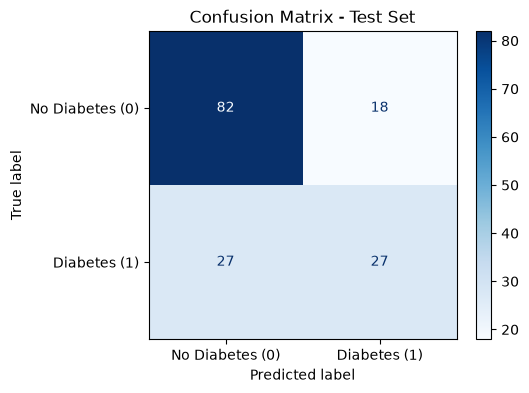

In [51]:
# Part 4.1 and 4.2: test predictions and evaluation metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate fresh predictions for the test dataset
y_test_pred = selected_model.predict(X_test_processed)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print('1) Predictions generated on test dataset.')
print('2) Test performance metrics:')
print(f'   Accuracy : {test_accuracy:.4f}')
print(f'   Precision: {test_precision:.4f}')
print(f'   Recall   : {test_recall:.4f}')
print(f'   F1-Score : {test_f1:.4f}')

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes (0)', 'Diabetes (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - Test Set')
ax.grid(False)
plt.show()

In [52]:
# Part 4.3 and 4.4: confusion matrix breakdown and train-vs-test comparison
tn, fp, fn, tp = cm.ravel()

print('3) Confusion matrix breakdown:')
print(f'   True Positives (TP):  {tp}')
print(f'   True Negatives (TN):  {tn}')
print(f'   False Positives (FP): {fp}')
print(f'   False Negatives (FN): {fn}')

part4_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [train_accuracy, train_precision, train_recall, train_f1],
    'Testing': [test_accuracy, test_precision, test_recall, test_f1]
})
part4_comparison['Gap (Train-Test)'] = part4_comparison['Training'] - part4_comparison['Testing']

print('\n4) Training vs testing performance comparison:')
display(part4_comparison.round(4))

3) Confusion matrix breakdown:
   True Positives (TP):  27
   True Negatives (TN):  82
   False Positives (FP): 18
   False Negatives (FN): 27

4) Training vs testing performance comparison:


,Metric,Training,Testing,Gap (Train-Test)
0,Accuracy,0.7964,0.7078,0.0886
1,Precision,0.7697,0.6000,0.1697
2,Recall,0.5935,0.5000,0.0935
3,F1-Score,0.6702,0.5455,0.1247


### Part 4 - Explanation

From the confusion matrix and metric comparison:
- The model correctly identifies many non-diabetic cases (higher TN).
- False negatives are substantial, which means some diabetic patients are missed.
- For a diabetes screening context, improving recall is important to reduce missed positive cases.
- Overall, the model shows moderate performance with room for improvement in sensitivity to class 1.

### Part 5 - Model Performance Analysis
Analyze the overall performance of the Machine Learning model and draw meaningful conclusions.

#### Tasks
1. Identify the most important performance metric for the diabetes prediction problem and explain why.
2. Discuss whether the model is performing well based on the evaluation results.
3. Identify potential limitations of the model.
4. Suggest at least two ways to improve model performance, such as:
   - a. Feature engineering
   - b. Hyperparameter tuning
   - c. Feature selection
   - d. Trying a different classification algorithm
   - e. Handling class imbalance

In [53]:
# Part 5: supporting calculations for performance analysis
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

part5_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'False Negative Rate'],
    'Value': [test_accuracy, test_precision, test_recall, test_f1, specificity, false_negative_rate]
})

print('Part 5 supporting metrics (test set):')
display(part5_summary.round(4))

print('\nFinal Model Performance Summary (dynamic):')
for _, row in part5_summary.iterrows():
    print(f"- Test {row['Metric']}: {row['Value']:.4f}")

Part 5 supporting metrics (test set):


,Metric,Value
0,Accuracy,0.7078
1,Precision,0.6000
2,Recall,0.5000
3,F1-Score,0.5455
4,Specificity,0.8200
5,False Negative Rate,0.5000



Final Model Performance Summary (dynamic):
- Test Accuracy: 0.7078
- Test Precision: 0.6000
- Test Recall: 0.5000
- Test F1-Score: 0.5455
- Test Specificity: 0.8200
- Test False Negative Rate: 0.5000


### Part 5 - Final Analysis

#### Final Model Performance Summary
- The run-specific metric values are reported in the Part 5 code output table above.
- This keeps the summary automatically updated on each rerun.

#### Key Findings
- The model performs moderately as a baseline classifier.
- Recall for the diabetic class is limited, and many positive cases can be missed.
- The model is stronger at identifying non-diabetic cases than diabetic cases.
- There is a mild train-test performance gap, suggesting some overfitting risk.

#### Most Important Metric and Reason
- Recall for the diabetic class is the most critical metric for screening use, because false negatives can delay diagnosis and treatment.

#### Model Limitations
- Class imbalance can bias predictions toward class 0.
- The available features may not capture all relevant clinical risk factors.
- Current model calibration/threshold may not be optimized for recall.

#### Recommendations for Improvement
- Tune the decision threshold to increase recall for class 1.
- Use class weighting (`class_weight='balanced'`) or resampling methods.
- Perform systematic hyperparameter tuning (GridSearchCV or RandomizedSearchCV).
- Try additional algorithms and probability calibration.
- Add feature engineering and outlier-robust preprocessing.